# 🧠 Fase 03 Entrenamiento Comparativo mediante Transfer Learning

**Objetivo del Notebook:**
Este cuaderno aborda el núcleo analítico del proyecto: el entrenamiento, validación y comparación de tres arquitecturas de Redes Neuronales Convolucionales (CNN) de última generación (**ResNet50, MobileNetV2 y EfficientNetB0**). 

Para mitigar el coste computacional y maximizar la capacidad de generalización sobre el dataset sintético de metales, se aplica el paradigma de **Transfer Learning**.

**Flujo de ejecución (*Pipeline*):**
1. **Extracción de características (*Feature Extraction*):** Congelación de las capas convolucionales base preentrenadas en ImageNet y entrenamiento exclusivo de la nueva capa densa de clasificación multiclase (5 categorías de defectos).
2. **Ajuste Fino (*Fine-Tuning*):** Descongelación controlada de las últimas capas de la base convolucional para adaptar los pesos a los descriptores morfológicos específicos del entorno industrial.
3. **Evaluación Cuantitativa:** Cálculo del *Classification Report* (Precision, Recall, F1-Score) y generación automatizada de las **Matrices de Confusión** para analizar la viabilidad industrial de cada modelo.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. ¡ACTUALIZADO! Cambiamos a 3 canales porque tu dataset ya viene en RGB
IMG_SHAPE = (224, 224, 3) 
NUM_CLASSES = 5
LR_FEATURE_EXTRACTION = 1e-3
LR_FINE_TUNING = 1e-5

def build_transfer_learning_model(base_architecture="resnet50"):
    """
    Construye un modelo de Transfer Learning.
    """
    # Entradas directamente en 3 canales
    inputs = layers.Input(shape=IMG_SHAPE, name="input_rgb")
    
    # Selección de la base convolucional preentrenada
    # Pasamos 'inputs' directamente, sin la capa Lambda
    if base_architecture == "resnet50":
        base_model = tf.keras.applications.ResNet50(
            include_top=False, weights="imagenet", input_tensor=inputs
        )
    elif base_architecture == "efficientnetb0":
        base_model = tf.keras.applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_tensor=inputs
        )
    elif base_architecture == "mobilenetv2":
        base_model = tf.keras.applications.MobileNetV2(
            include_top=False, weights="imagenet", input_tensor=inputs
        )
    else:
        raise ValueError("Arquitectura no soportada.")
        
    # FASE 1: Congelamos la base convolucional completa
    base_model.trainable = False
    
    # Construcción de la cabecera de clasificación personalizada
    x = base_model.output
    x = layers.GlobalAveragePooling2D(name="pooling_global")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", name="densa_intermedia")(x)
    x = layers.Dropout(0.4, name="dropout_regularizacion")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="capa_salida")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name=f"Model_{base_architecture}")
    return model, base_model

In [ ]:
# ==========================================
# Definición de rutas relativas (Multiplataforma)
# ==========================================
# Como los notebooks están en la carpeta 'notebooks/', 
# usamos '..' para subir a la raíz del proyecto y luego entramos en 'data'
DATA_DIR = os.path.join("..", "data", "industrial_defect_dataset")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
META_CSV = os.path.join(DATA_DIR, "metadata.csv")
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Cargando conjunto de entrenamiento...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Fundamental para usar Categorical Crossentropy
)

print("\nCargando conjunto de validación...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Extraemos el número real de clases (defectos) encontradas en las carpetas
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\nClases detectadas ({num_classes}): {class_names}")

# Habilitamos el Prefetching asíncrono para cargar los lotes directamente en la memoria RAM
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Cargando conjunto de entrenamiento...
Found 12000 files belonging to 5 classes.
Using 9600 files for training.

Cargando conjunto de validación...
Found 12000 files belonging to 5 classes.
Using 2400 files for validation.

Clases detectadas (5): ['crack', 'hole', 'normal', 'rust', 'scratch']


In [ ]:
# Configuración de hiperparámetros para las épocas
EPOCHS_PHASE_1 = 5   # Con 5 épocas suele bastar para asentar la cabecera
EPOCHS_PHASE_2 = 15  # Ajuste fino profundo

arquitecturas = ["resnet50", "efficientnetb0", "mobilenetv2"]
historiales_avanzados = {} # Diccionario para guardar resultados y hacer gráficas luego

# Mantenemos los callbacks de control
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, monitor='val_loss')
]

for arq in arquitecturas:
    print(f"\n{'='*60}\n🚀 INICIANDO ENTRENAMIENTO CON: {arq.upper()}\n{'='*60}")
    
    
    model, base_model = build_transfer_learning_model(arq)
    
    # ==========================================
    # FASE 1: Extracción de características
    # ==========================================
    print(f"\n--- FASE 1: Entrenando cabecera de {arq} (Capas base congeladas) ---")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FEATURE_EXTRACTION),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # Entrenamiento Fase 1
    history_p1 = model.fit(
        train_dataset,      
        validation_data=val_dataset, 
        epochs=EPOCHS_PHASE_1,
        callbacks=callbacks_tl
    )
    
    # ==========================================
    # FASE 2: Fine-Tuning (Ajuste Fino)
    # ==========================================
    print(f"\n--- FASE 2: Fine-Tuning de {arq} (Capas base descongeladas) ---")
    # Descongelamos la red base preentrenada
    base_model.trainable = True
    
    # Re-compilamos OBLIGATORIAMENTE con una tasa de aprendizaje bajísima (1e-5)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINE_TUNING),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # Entrenamiento Fase 2
    history_p2 = model.fit(
        train_dataset, 
        validation_data=val_dataset,
        epochs=EPOCHS_PHASE_2,
        callbacks=callbacks_tl
    )
    
    # Guardamos el historial completo para analizarlo después
    historiales_avanzados[arq] = {
        'fase1': history_p1.history,
        'fase2': history_p2.history
    }
    
    # Guardamos el modelo en formato .keras 
    model.save(f"modelo_optimo_{arq}.keras")
    print(f"✅ Modelo {arq.upper()} guardado con éxito en disco.")


🚀 INICIANDO ENTRENAMIENTO CON: RESNET50

--- FASE 1: Entrenando cabecera de resnet50 (Capas base congeladas) ---
Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 172s 565ms/step - accuracy: 0.9943 - loss: 0.0185 - val_accuracy: 0.9992 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 169s 565ms/step - accuracy: 0.9985 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 1.6547e-04 - learning_rate: 0.0010
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 171s 569ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 6.0844e-05 - learning_rate: 0.0010
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 175s 584ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9996 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 176s 588ms/step - accuracy: 0.9984 - loss: 0.0142 - val_accuracy: 0.9996 - val_loss: 0.0107 - learning_rate: 0.0010

--- FASE 2: Fine-Tuning de resnet50 (Capas base descongeladas) ---
Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━


--- FASE 1: Entrenando cabecera de mobilenetv2 (Capas base congeladas) ---
Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9408 - loss: 0.1839 - val_accuracy: 0.9708 - val_loss: 0.0843 - learning_rate: 0.0010
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - accuracy: 0.9728 - loss: 0.0790 - val_accuracy: 0.9767 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - accuracy: 0.9835 - loss: 0.0523 - val_accuracy: 0.9812 - val_loss: 0.0507 - learning_rate: 5.0000e-04

--- FASE 2: Fine-Tuning de mobilenetv2 (Capas base descongeladas) ---
Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 289s 922ms/step - accuracy: 0.9125 - loss: 0.2966 - val_accuracy: 0.8542 - val_loss: 0.5717 - learning_rate: 1.0000e-05
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 291s 969ms/step - accuracy: 0.9943 - loss: 0.0232 - val_accuracy: 0.9558 - val_loss: 0.1719 - learning_rate: 1.0000e-05
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 293s 976ms/step - accuracy:

Cargando modelo_optimo_resnet50.keras desde el disco...

--- FASE 3: Evaluación de Rendimiento Final para modelo_optimo_resnet50.keras ---
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 434ms/step - accuracy: 0.9837 - loss: 0.0749

=> Validation Loss Final: 0.0749
=> Validation Accuracy Final: 0.9837

Generando predicciones sobre el conjunto de validación...
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 432ms/step

--- REPORTE DE CLASIFICACIÓN: modelo_optimo_resnet50.keras ---
              precision    recall  f1-score   support

       crack       1.00      0.98      0.99       463
        hole       0.99      1.00      1.00       466
      normal       0.99      0.96      0.97       497
        rust       0.94      1.00      0.97       467
     scratch       1.00      0.99      0.99       507

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
weighted avg       0.98      0.98      0.98      2400


[OK] Matriz de confusión guardada como: matriz_confusion_mo

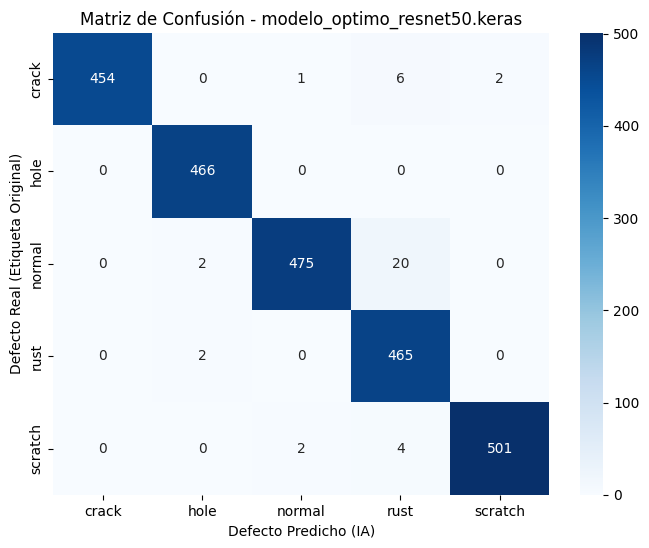

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# ==================================================
# FASE 3: EVALUACIÓN AUTOMÁTICA Y MATRIZ RESNET50
# ==================================================
 
 

# 1. Le decimos el nombre exacto de tu archivo
arq = "modelo_optimo_resnet50.keras"

# 2. Obligamos a Python a cargar este modelo desde mi  disco duro
print(f"Cargando {arq} desde el disco...")
model = load_model(arq)



print(f"\n--- FASE 3: Evaluación de Rendimiento Final para {arq} ---")

# 1. Extraer el Loss y Accuracy definitivo
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"\n=> Validation Loss Final: {val_loss:.4f}")
print(f"=> Validation Accuracy Final: {val_accuracy:.4f}")

print(f"\nGenerando predicciones sobre el conjunto de validación...")

# 2. Extraer las etiquetas reales (y_true) del dataset
y_true = []
for images, labels in val_dataset:
    # Como usamos categorical_crossentropy, pasamos de One-Hot a números enteros
    y_true.extend(np.argmax(labels.numpy(), axis=1)) 
y_true = np.array(y_true)

# 3. Generar las predicciones del modelo (y_pred)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Nombres  5 clases  Defecto (El orden alfabético de Keras por defecto)
class_names = ['crack', 'hole', 'normal', 'rust', 'scratch']

# 4. Calcular e imprimir el Reporte de Clasificación (F1-Score, Recall, Precision)
print(f"\n--- REPORTE DE CLASIFICACIÓN: {arq} ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Dibujar la Matriz de Confusión visual
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusión - {arq}")
plt.ylabel('Defecto Real (Etiqueta Original)')
plt.xlabel('Defecto Predicho (IA)')

# Guardamos la imagen automáticamente en el disco duro
nombre_archivo_matriz = f"matriz_confusion_{arq}.png"
plt.savefig(nombre_archivo_matriz, dpi=300, bbox_inches='tight')
print(f"\n[OK] Matriz de confusión guardada como: {nombre_archivo_matriz}")

plt.show() 


--- FASE 3: Evaluación de Rendimiento Final para modelo_optimo_efficientnetb0.keras ---
Cargando modelo_optimo_efficientnetb0.keras desde el disco...
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step - accuracy: 0.9204 - loss: 0.3112

=> Validation Loss Final: 0.3112
=> Validation Accuracy Final: 0.9204

Generando predicciones sobre el conjunto de validación...
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 205ms/step

--- REPORTE DE CLASIFICACIÓN: modelo_optimo_efficientnetb0.keras ---
              precision    recall  f1-score   support

       crack       0.98      0.85      0.91       463
        hole       0.99      0.91      0.95       466
      normal       0.74      0.99      0.85       497
        rust       0.99      0.98      0.98       467
     scratch       1.00      0.87      0.93       507

    accuracy                           0.92      2400
   macro avg       0.94      0.92      0.92      2400
weighted avg       0.94      0.92      0.92      2400


[OK] Matriz de confusión guardada como: m

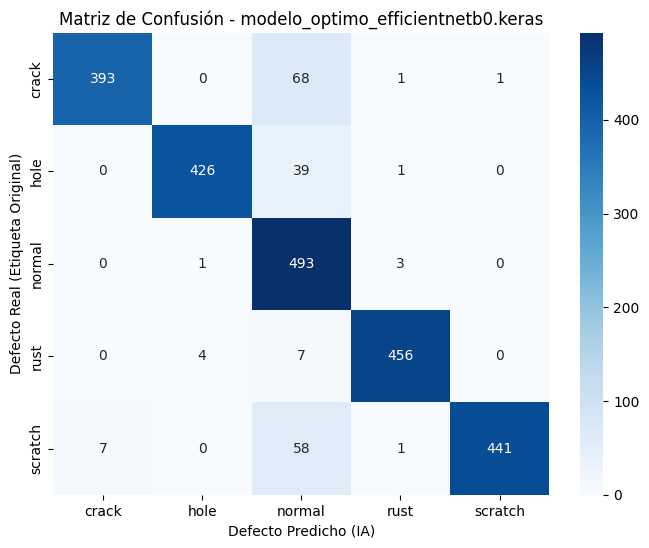

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# =====================================================
# FASE 3: EVALUACIÓN AUTOMÁTICA Y MATRIZ EFFICIENTNETB0
# =====================================================

arq = "modelo_optimo_efficientnetb0.keras"
print(f"\n--- FASE 3: Evaluación de Rendimiento Final para {arq} ---")
print(f"Cargando {arq} desde el disco...")
model = load_model(arq)



# 1. Extraer el Loss y Accuracy definitivo
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"\n=> Validation Loss Final: {val_loss:.4f}")
print(f"=> Validation Accuracy Final: {val_accuracy:.4f}")

print(f"\nGenerando predicciones sobre el conjunto de validación...")

# 2. Extraer las etiquetas reales (y_true) del dataset
y_true = []
for images, labels in val_dataset:
    # Como usamos categorical_crossentropy, pasamos de One-Hot a números enteros
    y_true.extend(np.argmax(labels.numpy(), axis=1)) 
y_true = np.array(y_true)

# 3. Generar las predicciones del modelo (y_pred)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Nombres de las 5 clases de defecto  (El orden alfabético de Keras por defecto)
class_names = ['crack', 'hole', 'normal', 'rust', 'scratch']

# 4. Calcular e imprimir el Reporte de Clasificación (F1-Score, Recall, Precision)
print(f"\n--- REPORTE DE CLASIFICACIÓN: {arq} ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Dibujar la Matriz de Confusión visual
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusión - {arq}")
plt.ylabel('Defecto Real (Etiqueta Original)')
plt.xlabel('Defecto Predicho (IA)')

# Guardamos la imagen automáticamente en el disco duro
nombre_archivo_matriz = f"matriz_confusion_{arq}.png"
plt.savefig(nombre_archivo_matriz, dpi=300, bbox_inches='tight')
print(f"\n[OK] Matriz de confusión guardada como: {nombre_archivo_matriz}")

plt.show() 


--- FASE 3: Evaluación de Rendimiento Final para modelo_optimo_mobilenetv2.keras ---
Cargando modelo_optimo_mobilenetv2.keras desde el disco...
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.8542 - loss: 0.5717

=> Validation Loss Final: 0.5717
=> Validation Accuracy Final: 0.8542

Generando predicciones sobre el conjunto de validación...
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step

--- REPORTE DE CLASIFICACIÓN: modelo_optimo_mobilenetv2.keras ---
              precision    recall  f1-score   support

       crack       0.78      1.00      0.87       463
        hole       0.72      1.00      0.84       466
      normal       0.97      0.96      0.97       497
        rust       1.00      0.36      0.52       467
     scratch       0.96      0.94      0.95       507

    accuracy                           0.85      2400
   macro avg       0.88      0.85      0.83      2400
weighted avg       0.89      0.85      0.83      2400


[OK] Matriz de confusión guardada como: matriz_con

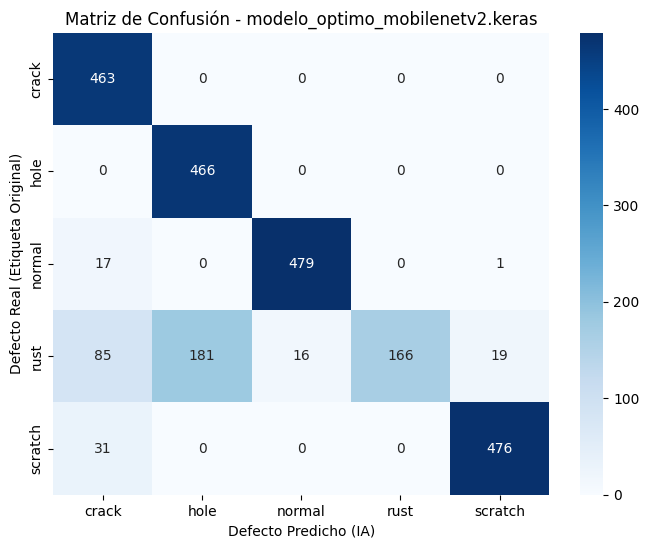

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ======================================================
# FASE 3: EVALUACIÓN AUTOMÁTICA Y MATRIZ  MOBILENETV2
# ======================================================

arq = "modelo_optimo_efficientnetb0.keras"
arq = "modelo_optimo_mobilenetv2.keras"
print(f"\n--- FASE 3: Evaluación de Rendimiento Final para {arq} ---")
print(f"Cargando {arq} desde el disco...")
model = load_model(arq)



# 1. Extraer el Loss y Accuracy definitivo
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"\n=> Validation Loss Final: {val_loss:.4f}")
print(f"=> Validation Accuracy Final: {val_accuracy:.4f}")

print(f"\nGenerando predicciones sobre el conjunto de validación...")

# 2. Extraer las etiquetas reales (y_true) del dataset
y_true = []
for images, labels in val_dataset:
    # Como usamos categorical_crossentropy, pasamos de One-Hot a números enteros
    y_true.extend(np.argmax(labels.numpy(), axis=1)) 
y_true = np.array(y_true)

# 3. Generar las predicciones del modelo (y_pred)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Nombres de las 5 clases de defecto (El orden alfabético de Keras por defecto)
class_names = ['crack', 'hole', 'normal', 'rust', 'scratch']

# 4. Calcular e imprimir el Reporte de Clasificación (F1-Score, Recall, Precision)
print(f"\n--- REPORTE DE CLASIFICACIÓN: {arq} ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Dibujar la Matriz de Confusión visual
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusión - {arq}")
plt.ylabel('Defecto Real (Etiqueta Original)')
plt.xlabel('Defecto Predicho (IA)')

# Guardamos la imagen automáticamente en el disco duro
nombre_archivo_matriz = f"matriz_confusion_{arq}.png"
plt.savefig(nombre_archivo_matriz, dpi=300, bbox_inches='tight')
print(f"\n[OK] Matriz de confusión guardada como: {nombre_archivo_matriz}")

plt.show() 